# Preliminaries

In [1]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *
from sympy.assumptions import Q

# ploting customizations
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25,
          'animation.embed_limit': 2**128,
          'font.family': 'serif',
          'mathtext.fontset': 'cm'}
plt.rcParams.update(params)
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

%matplotlib inline
from matplotlib import colormaps
from mpl_toolkits.mplot3d import axes3d

# for animations
from matplotlib import animation, rc
from IPython.display import HTML

# numerics
import numpy as np
from scipy.integrate import solve_ivp, solve_bvp
from scipy.integrate import trapezoid, cumulative_trapezoid
from scipy import fft
from scipy.interpolate import griddata
from scipy.special import jv, iv

# to save plots as files and download them
#from google.colab import files

# Method of Pande _et al._ (2023)

Common variables, some are explicitly real.

In [2]:
beta, sigma, Wo, St = sp.symbols('beta, sigma, Wo, St', real=True, positive=True)
P, Y, Z, T = sp.symbols('P, Y, Z, T', real=True)
kappa = sp.symbols('kappa', zero=False)
# nonzero=True means "real and not zero", whereas zero=False just means "not zero"

The governing PDE is
$$
   \frac{\partial }{\partial Z} \Bigg\{ \frac{\partial P}{\partial Z} {\mathfrak{G}(\beta P;\mathrm{Wo})} \Bigg\}  = 2 \hat{\mathrm{St}} \left(1+\beta\Re[P]\right) \frac{\partial P}{\partial T},
$$
where
$$
  \mathfrak{G}(\beta P; \mathrm{Wo}) = \left(1+ \beta \Re[P]\right)^2 \frac{1}{i \mathrm{Wo}^2} \left[1-\frac{2J_1\left(i^{3/2} {\mathrm{Wo}} \left(1+\beta \Re[P]\right)\right)}{i^{3/2} {\mathrm{Wo}} \left(1+\beta \Re[P]\right) J_0\left(i^{3/2} {\mathrm{Wo}} \left(1+\beta \Re[P]\right)\right)}\right].
$$

## Perturbation expansion

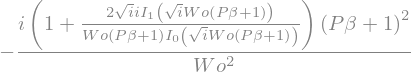

In [3]:
G = (1 + beta*P)**2*1/(sp.I*Wo**2) \
    * (1 - 2*sp.besselj(1,sp.I**sp.Rational(3,2)*Wo*(1+beta*P)) \
           /sp.besselj(0,sp.I**sp.Rational(3,2)*Wo*(1+beta*P)) \
           /(sp.I**sp.Rational(3,2)*Wo*(1+beta*P)) )

display(G)

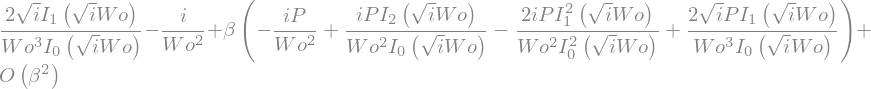

In [4]:
Gseries = sp.series(G,beta,0,2)
display(Gseries)

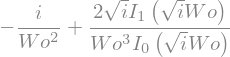

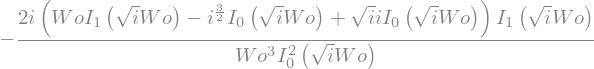

In [5]:
G0 = sp.limit(Gseries,beta,0).simplify()
display(G0)
G1 = sp.limit((Gseries-G0)/(beta*P),beta,0).simplify()
display(G1)

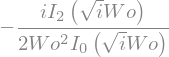

In [6]:
sp.besseli(2,sp.I**sp.Rational(1,2)*Wo)/2/sp.I/Wo**2/sp.besseli(0,sp.I**sp.Rational(1,2)*Wo)

In [7]:
# check that G0 is the same as in Zhang and Rallabandi (2024)
sp.Eq(G0,sp.besseli(2,sp.I**sp.Rational(1,2)*Wo)/sp.I/Wo**2/sp.besseli(0,sp.I**sp.Rational(1,2)*Wo)).simplify()

In [8]:
# check that G1 is the same as in Pande et al. (2023)
sp.Eq(G1,-2*sp.besselj(1,sp.I**sp.Rational(3,2)*Wo)**2/sp.I/Wo**2/sp.besselj(0,sp.I**sp.Rational(3,2)*Wo)**2).simplify()

### At O(1)

At $\mathrm{O}(1)$, we have:
\begin{align*}
    \mathfrak{g}_0 \frac{\partial^2 P_0}{\partial Z^2} &= 2\hat{\mathrm{St}}\frac{\partial P_0}{\partial T}\\
    P_0(0,T) &= \tfrac{1}{2}e^{i T} + \mathrm{c.c.},\\
    P_0(1,T) &= 0.
\end{align*}
We posit that the $\mathrm{O}(1)$ problem has a solution of the form
$$
    P_0(Z,T) = \tfrac{1}{2}P_{0,1,a}(Z) e^{i T} + \mathrm{c.c.}.
$$

In [9]:
g0, g1 = sp.symbols('g0, g1')

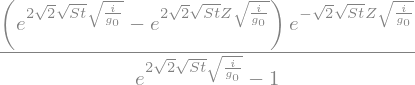

In [10]:
f = sp.Function('f')
P01asol = sp.dsolve(g0*f(Z).diff(Z,Z) - 2*St*sp.I*f(Z),
                    f(Z), ics={f(0):1, f(1):0}).rhs.simplify()
display(P01asol)

In [11]:
lam_P01_PWC23 = sp.lambdify((Z,T,St,Wo), sp.re(P01asol.subs(g1,G1).subs(g0,G0)*sp.exp(sp.I*T)))
lam_P01_PWC23_complex = sp.lambdify((Z,T,St,Wo), P01asol.subs(g1,G1).subs(g0,G0)*sp.exp(sp.I*T))

In [12]:
#f = sp.Function('f')
#P01asol = sp.dsolve(f(Z).diff(Z,Z) - kappa**2*f(Z), f(Z),
#                    ics={f(0):1, f(1):0}).rhs.rewrite(sp.sin).trigsimp()
#display(P01asol)

In [13]:
#sp.Eq(P01asol,P0a).simplify()

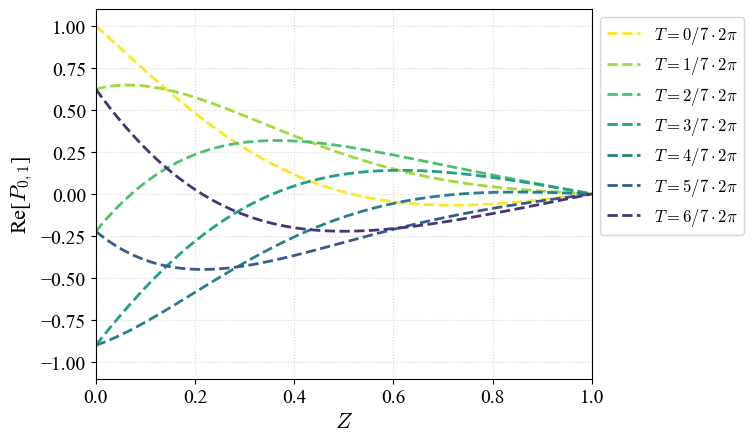

Wo = 1, St = 1


In [14]:
my_St = 1
my_Wo = 1

my_Z = np.linspace(0,1,100,endpoint=True)

ax = plt.gca()
ax.set_xlabel('$Z$')
ax.set_ylabel('Re[$P_{0,1}$]')
ax.set_xlim(0, 1)
ax.set_ylim(-1.1, 1.1)

# https://matplotlib.org/stable/users/explain/colors/colormaps.html#sequential
cmap = colormaps['viridis_r']

jmax = 7
for j in range(0,jmax):
  my_P01 = lam_P01_PWC23(my_Z,j/jmax*2*np.pi,my_St,my_Wo)
  ax.plot(my_Z, my_P01, lw=2, ls='dashed',
          label=rf'$T={j}/{jmax}\cdot 2\pi$', color=cmap(j/jmax))

ax.grid(alpha=0.5, linestyle='dotted')

# put a legend to the right of the current axis
ax.legend(bbox_to_anchor=(1, 1))

plt.show()

print(f'Wo = {my_Wo}, St = {my_St}')

### At O(β)

At $\mathrm{O}(\beta)$, we have:
$$\begin{align*}
    \mathfrak{g}_0 \frac{\partial^2 P_1}{\partial Z^2} +
    \mathfrak{g}_1 \frac{\partial}{\partial Z} \left(P_0\frac{\partial P_0}{\partial Z}\right)
    &= 2\hat{\mathrm{St}} \frac{\partial P_1}{\partial T} + 2\hat{\mathrm{St}} P_0 \frac{\partial P_0}{\partial T}, \\
    P_1(0,T) &= 0, \\
    P_1(1,T) &= 0.
\end{align*}$$
We may posit that the $\mathrm{O}(\beta)$ problem has a solution of the form
$$
    P_1(Z,T) = \tfrac{1}{2} P_{1,0,a}(Z) e^{0i T} + \tfrac{1}{2} \underbrace{P_{1,1,a}(Z)}_{=0} e^{1i T} + \tfrac{1}{2}  P_{1,2,a}(Z) e^{2i T} + \mathrm{c.c.}.
$$
The steady term, $P_{1,0} \equiv P_{1,0,a}$, satisfies
$$
    \mathfrak{g}_0 \frac{\partial^2 P_{1,0,a}}{\partial Z^2} + \frac{1}{2} \mathfrak{g}_1 \frac{\partial}{\partial Z} \left(P_{0,1,a}^* \frac{\partial P_{0,1,a}}{\partial Z}\right) - i \hat{\mathrm{St}} P_{0,1,a}^* P_{0,1,a} = 0,
$$
where the $*$ superscript denotes complex conjugate.

This is an ODE for $P_{1,0,a}$ that we **could try** to solve with SymPy...

In [15]:
# f = sp.Function('f')
# P10asol = sp.dsolve(g0*f(Z).diff(Z,Z) + sp.Rational(1,2)*g1*(sp.conjugate(P01asol)*P01asol.diff(Z)).diff(Z) - St*sp.conjugate(P01asol)*sp.I*P01asol,
#                     f(Z), ics={f(0):0, f(1):0}).rhs #.simplify()
# #P10asol = sp.refine(P10asol,sp.Ne(St**sp.Rational(3,2)*sp.sqrt(sp.I/g0),0) & sp.Ne(St**sp.Rational(1,2)*sp.sqrt(sp.I/g0),0))
# display(P10asol)

In [16]:
#sp.refine(P10asol,sp.Ne(St**sp.Rational(1,2)*sp.sqrt(sp.I/g0),0))

In [17]:
# The streaming pressure is <P_1> = 1/2 * P_{1,0,a}(Z) + c.c. = Re[P_{1,0,a}(Z)].
# lam_streamP_PWC23 = sp.lambdify((Z,St,Wo), sp.re(P10asol.subs(g1,G1).subs(g0,G0)))
# lam_streamP_PWC23_complex = sp.lambdify((Z,St,Wo), P10asol.subs(g1,G1).subs(g0,G0))

...or we can use a solution from Mathematica, but coded with `numpy` for speed.

In [18]:
def lam_streamP_PWC23_complex(Z,St,Wo):
  g0 = (-1j*Wo*iv(0, np.sqrt(1j)*Wo) + 2*np.sqrt(1j)*iv(1, np.sqrt(1j)*Wo))/(Wo**3*iv(0, np.sqrt(1j)*Wo))
  g1 = -2*1j*(Wo*iv(1, np.sqrt(1j)*Wo) - 1j**(3/2)*iv(0, np.sqrt(1j)*Wo) + np.sqrt(1j)*1j*iv(0, np.sqrt(1j)*Wo))*iv(1, np.sqrt(1j)*Wo)/(Wo**3*iv(0, np.sqrt(1j)*Wo)**2)
  kappa = np.sqrt(2*St*1j/g0)

  P10asol = \
  -0.015625*(kappa*(g1*np.power(kappa,2) - \
  4*1j*St)*np.conjugate(kappa)*(-2*Z + np.cos(2*(-1 + \
  Z)*np.imag(kappa)) + 2*(-1 + \
  Z)*np.cosh(kappa)*np.cosh(np.conjugate(kappa)) + np.cosh(2*(-1 + \
  Z)*np.real(kappa))) - g1*kappa*np.power(np.conjugate(kappa),3)*(-2*Z \
  + np.cos(2*(-1 + Z)*np.imag(kappa)) + 2*(-1 + \
  Z)*np.cosh(kappa)*np.cosh(np.conjugate(kappa)) + np.cosh(2*(-1 + \
  Z)*np.real(kappa))) + np.power(kappa,2)*(g1*np.power(kappa,2) - \
  2*1j*St)*(np.cos(2*(-1 + Z)*np.imag(kappa)) - np.cosh(2*(-1 + \
  Z)*np.real(kappa)) - 2*(-1 + \
  Z)*np.sinh(kappa)*np.sinh(np.conjugate(kappa))) + \
  (g1*np.power(kappa,2) + \
  2*1j*St)*np.power(np.conjugate(kappa),2)*(-np.cos(2*(-1 + \
  Z)*np.imag(kappa)) + np.cosh(2*(-1 + Z)*np.real(kappa)) + 2*(-1 + \
  Z)*np.sinh(kappa)*np.sinh(np.conjugate(kappa))))/(g0*np.power(np.\
  absolute(np.sinh(kappa)),2)*np.power(np.imag(kappa),2)*np.power(np.\
  real(kappa),2))

  return P10asol

def lam_streamP_PWC23(Z,St,Wo):
  return np.real(lam_streamP_PWC23_complex(Z,St,Wo))

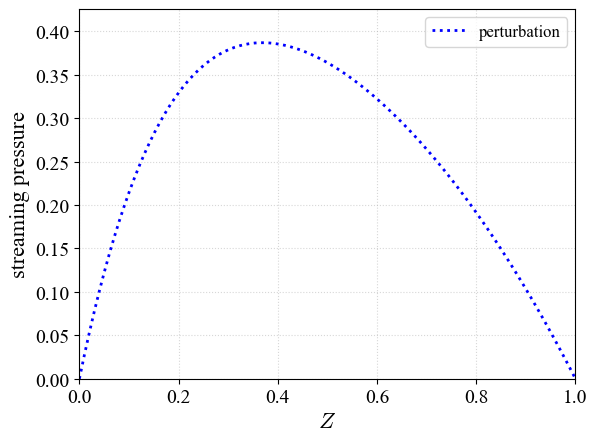

Wo = 1, St = 0.5


In [19]:
my_St = 0.5
my_Wo = 1

my_Z = np.linspace(0,1,100,endpoint=True)
my_streamP = lam_streamP_PWC23(my_Z,my_St,my_Wo)

ax = plt.gca()
ax.set_xlabel('$Z$')
ax.set_ylabel('streaming pressure')
ax.set_xlim(0, 1)
# casting to float due to weird behavior with lambdify
ax.set_ylim(0, float(my_streamP.max())*1.1)

ax.plot(my_Z, my_streamP, ls='dotted', color='blue', lw=2, label='perturbation')

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

plt.show()

print(f'Wo = {my_Wo}, St = {my_St}')

The second-harmonic term, $P_{1,2}$, satisfies
$$
    \mathfrak{g}_0 \frac{\partial^2 P_{1,2,a}}{\partial Z^2}
    + \frac{1}{2} \mathfrak{g}_1 \frac{\partial}{\partial Z} \left( P_{0,1,a} \frac{\partial P_{0,1,a}}{\partial Z} \right) - 4i \hat{\mathrm{St}} P_{1,2,a} - i \hat{\mathrm{St}} P_{0,1,a}P_{0,1,a} = 0.
$$
This is once again an ODE for $P_{1,2,a}$.

We will not attempt its solution here.

In [20]:
#f = sp.Function('f')
#P12asol = sp.dsolve(f0*f(Z).diff(Z,Z) + sp.Rational(1,2)*f1*(P01asol*P01asol.diff(Z)).diff(Z) - 4*sp.I*St*f(Z) - sp.I*St*P10asol*P10asol,
#                    f(Z), ics={f(0):0, f(1):0}).rhs.simplify()
#P12asol = sp.refine(P12asol,sp.Ne(sp.sqrt(St)*sp.sqrt(sp.I/f0),0))
#display(P12asol)

## Numerical solution of the PDE

We turn the PDE into a semi-discrete system of ODEs by the [method of lines](https://reference.wolfram.com/language/tutorial/NDSolveMethodOfLines.html).

We apply flux-conservative central differencing, staggering the nonlinear terms (see [GC19]).

For the interior nodes ($j=1,\dots,N-2$), we have
$$
   \dot{P}_j = \frac{1}{2 \hat{\mathrm{St}} \left(1+\beta P_j\right)} \frac{ S_{j+1/2} \mathfrak{G}(\beta P_{j+1/2};\mathrm{Wo}) - S_{j-1/2} \mathfrak{G}(\beta P_{j-1/2};\mathrm{Wo})}{\Delta Z},
$$
where
$$
\begin{alignat*}{3}
  S_{i+1/2} &:= \left.\frac{\partial P}{\partial Z}\right|_{z_{j+1/2}} \approx \frac{P_{i+1} - P_{i}}{\Delta Z}, &\qquad P_{i+1/2} &\approx \frac{P_{i+1} + P_{i}}{2},\\
  S_{i-1/2} &:= \left.\frac{\partial P}{\partial Z}\right|_{z_{j-1/2}} \approx \frac{P_i - P_{i-1}}{\Delta Z}, &\qquad P_{i-1/2} &\approx \frac{P_i + P_{i-1}}{2},\\
\end{alignat*}
$$
and
and $P_j(T) \approx P(Z_j,T)$, where $Z_j = jh$ with $h=1/N$ being the grid spacing.

At $Z=0$ ($j=0$) and $Z=1$ ($j=N-1$), we to impose the Dirichlet BCs,
$$
\begin{align*}
  P_0(T) &= \tfrac{1}{2}e^{iT}+\mathrm{c.c.}
=\cos T, \\
  P_{N-1}(T) &= 0.
\end{align*}
$$

In [21]:
# number of grid points in discretization
N = 500
# grid spacing
dZ = 1/N
# the grid
Zj = np.linspace(0,1,num=N,endpoint=True)
# number of periods of numerical integration
Tmax = 8*(2*np.pi)

In [22]:
def mathfrak_G(betaP,Wo):
  #betaP = np.real(betaP) # if we wish to do it as in PWC23
  return (1 + betaP)**2*1/(1j*Wo**2) \
           * (1 - 2*jv(1,1j**(3/2)*Wo*(1+betaP)) \
             /(1j**(3/2)*Wo*(1+betaP) * jv(0,1j**(3/2)*Wo*(1+betaP))))

In [23]:
def P_left_BC(T):
  return np.cos(T) #np.exp(1j*T)

def P_right_BC(T):
  return 0.

In [24]:
# semi-discrete ODE system's right-hand side
def PWC23_PDE_RHS(T,P,beta,St,Wo):
  #RHS = np.empty(N-2, dtype=complex)

  # prepare arrays of P and S and j +/- 1/2 & use Dirichlet BC
  Pm12 = (P + np.concatenate(([P_left_BC(T)], P[0:N-3])))/2
  Pp12 = (np.concatenate((P[1:N-2], [P_right_BC(T)])) + P)/2
  Sm12 = (P - np.concatenate(([P_left_BC(T)], P[0:N-3])))/dZ
  Sp12 = (np.concatenate((P[1:N-2], [P_right_BC(T)])) - P)/dZ

  # all nodes, per the formula
  return (mathfrak_G(beta*Pp12,Wo)*Sp12 - mathfrak_G(beta*Pm12,Wo)*Sm12)/dZ \
         /(St*2*(1+beta*P))

  #return RHS

Note that the `Radau` and `LSODA` methods from `solve_ivp` cannot be used in the complex domain.

The problem is stiff so all the Runge&ndash;Kutta methods are slow. `BDF` works well.

In [25]:
my_beta = 0.1
my_St = 0.5
my_Wo = 1

# integration method and solver tolerance(s)
intmeth = 'BDF'
tol = 1e-8

# use the P_{0,1} complex solution as the IC to reduce the transient
Pic = lam_P01_PWC23_complex(Zj,0,my_St,my_Wo)[1:N-1] #np.zeros(N-2, dtype=complex)

# simulate the PDE
sol = solve_ivp(fun=lambda T, P: PWC23_PDE_RHS(T,P,my_beta,my_St,my_Wo),
                t_span=[0,Tmax], y0=Pic,
                method=intmeth, rtol=tol, atol=tol, dense_output=True)

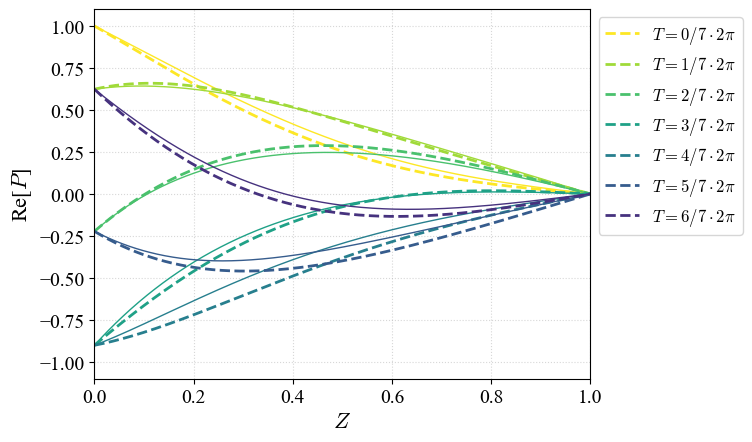

beta = 0.1, Wo = 1, St = 0.5
dashed = perturbation, solid = PDE


In [26]:
ax = plt.gca()
ax.set_xlabel('$Z$')
ax.set_ylabel('Re[$P$]')
ax.set_xlim(0, 1)
ax.set_ylim(-1.1, 1.1)

# https://matplotlib.org/stable/users/explain/colors/colormaps.html#sequential
cmap = colormaps['viridis_r']

T0 = Tmax-2*np.pi
jmax = 7
for j in range(0,jmax):
  Tj = T0+j/jmax*2*np.pi
  my_P01 = lam_P01_PWC23(Zj,Tj,my_St,my_Wo)
  ax.plot(Zj, my_P01, lw=2, ls='dashed', label=rf'$T={j}/{jmax}\cdot 2\pi$', color=cmap(j/jmax))
  Pj = np.concatenate(([P_left_BC(Tj)], sol.sol(Tj), [P_right_BC(Tj)]))
  ax.plot(Zj, np.real(Pj), lw=1, color=cmap(j/jmax))

ax.grid(alpha=0.5, linestyle='dotted')

# put a legend to the right of the current axis
ax.legend(bbox_to_anchor=(1, 1))

plt.show()

print(f'beta = {my_beta}, Wo = {my_Wo}, St = {my_St}')
print('dashed = perturbation, solid = PDE')

### Streaming: PDE vs perturbation

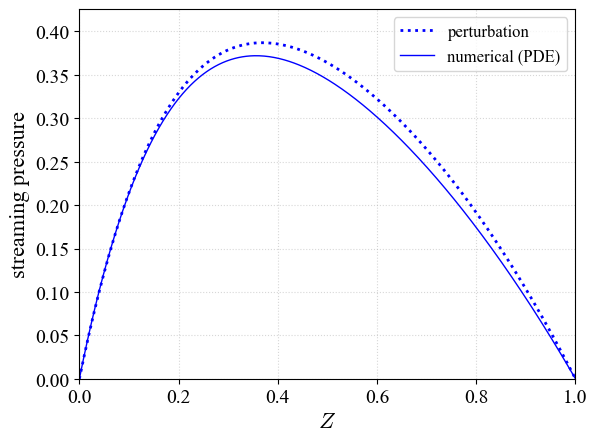

beta = 0.1, Wo = 1, St = 0.5


In [27]:
my_streamP = lam_streamP_PWC23(Zj,my_St,my_Wo)
my_Ts = np.linspace(T0,T0+2*np.pi,50,endpoint='True')

sol_space_time = np.concatenate(([P_left_BC(my_Ts)], sol.sol(my_Ts), [0*P_left_BC(my_Ts)]))
my_numerical_streamP = np.real(1/(2*np.pi)*trapezoid(sol_space_time,my_Ts,axis=1)/my_beta)

ax = plt.gca()
ax.set_xlabel('$Z$')
ax.set_ylabel('streaming pressure')
ax.set_xlim(0, 1)
# casting to float due to weird behavior with lambdify
ylim_max = float(1.1*max(np.max(my_streamP),
                         np.max(my_numerical_streamP)))
ax.set_ylim(0, ylim_max)

ax.plot(Zj, my_streamP, lw=2, ls='dotted', color='blue', label='perturbation')
ax.plot(Zj, my_numerical_streamP, lw=1, color='blue', label='numerical (PDE)')

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

plt.show()

print(f'beta = {my_beta}, Wo = {my_Wo}, St = {my_St}')

# Method of Zhang &amp; Rallabandi (2024)

In [28]:
kappa = sp.symbols('kappa')
Wo, R, Z, T = sp.symbols('Wo, R, Z, T', real=True)

As with the method of Pande _et al._ (2023), $P_0(Z,T) = P_{0,a}(Z) e^{iT}$, where
$$
  P_{0,a}(Z) = \frac{\sinh\big(\kappa(1-Z)\big)}{\sinh \kappa},\qquad \kappa(\mathrm{Wo}) := \sqrt{\frac{2i\sigma}{\mathfrak{g}_0(\mathrm{Wo})}},\quad \sigma \equiv \hat{\mathrm{St}}.
$$

In [29]:
P0a = sp.sinh(kappa*(1-Z))/sp.sinh(kappa)
P0 = P0a*sp.exp(sp.I*T)

We found $V_{z,0}(R,Z,T) = V_{z,0,a}(R,Z) e^{iT}$, where
$$
    V_{z,0,a}(R,T) =
    \frac{1}{i\mathrm{Wo}^2}\left[1-\frac{J_0(i^{3/2} \mathrm{Wo} \,R)}{J_0(i^{3/2} \mathrm{Wo} )}\right] \left( -\frac{d P_{0,a}}{d Z} \right)
$$
in terms of $P_{0,a}$ above.

In [30]:
Vz0a = 1/(sp.I*Wo**2)*(1 - sp.besselj(0,sp.I**sp.Rational(3,2)*Wo*R) \
                           /sp.besselj(0,sp.I**sp.Rational(3,2)*Wo))*(-P0a.diff(Z))
Vz0 = Vz0a*sp.exp(sp.I*T)

From the COM equation,
$$
  \frac{1}{R}\frac{\partial(R V_{R,0,a})}{\partial R} + \frac{\partial V_{z,0,a}}{\partial Z} = 0,
$$
the radial velocity $V_{R,0,a}$ is found as the solution of an ODE with $V_{z,0,a}$ given as above.

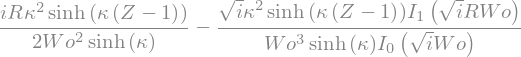

In [31]:
f = sp.Function('f')
Vr0a = sp.dsolve(1/R*(R*f(R)).diff(R) + Vz0a.diff(Z), f(R)).rhs #.simplify()
# apply centerline condition by hand to find constant of integration
my_C1 = sp.solve(sp.limit(R**2*Vr0a.diff(R),R,0))[0]
Vr0a = Vr0a.subs({sp.Symbol('C1'): my_C1})
display(Vr0a)
Vr0 = Vr0a*sp.exp(sp.I*T)

First, assume $\langle V_{z,1}^\mathrm{adv} \rangle$=0, and we wish to evaluate
$$
    \langle Q_1 \rangle = 2\pi \int_0^1 \left[ -\frac{1}{2}\left.\left\langle P_0 \frac{\partial V_{z,0}}{\partial R} \right|_{R=1}\right\rangle  \right]dZ
$$
and
$$
    \langle P_1 \rangle(Z) = 16 \int_0^Z \left[ -\frac{1}{2}\left.\left\langle P_0 \frac{\partial V_{z,0}}{\partial R} \right|_{R=1}\right\rangle \right] dZ - \frac{8}{\pi} Z \langle Q_1 \rangle
$$
using the identity $\langle A B \rangle = \tfrac{1}{2}\Re[A^*B]$.

In [32]:
Q1_ZR24 = 2*sp.pi*sp.re(sp.integrate((-1/2)*(1/2)*sp.conjugate(P0)*Vz0.diff(R).subs(R,1),(Z,0,1))).subs(kappa,sp.sqrt(2*sp.I*St/G0))

In [33]:
ZZ = sp.Symbol('ZZ')
P1_ZR24 = 16*sp.re(sp.integrate((-1/2)*(1/2)*sp.conjugate(P0)*Vz0.diff(R).subs(R,1),(Z,0,ZZ))).subs(kappa,sp.sqrt(2*sp.I*St/G0)).subs(ZZ,Z) - (8/sp.pi)*Z*Q1_ZR24

In [34]:
# this P_1 is the streaming pressure, by construction, in ZR24
lam_streamP_ZR24 = sp.lambdify((Z,St,Wo), P1_ZR24)

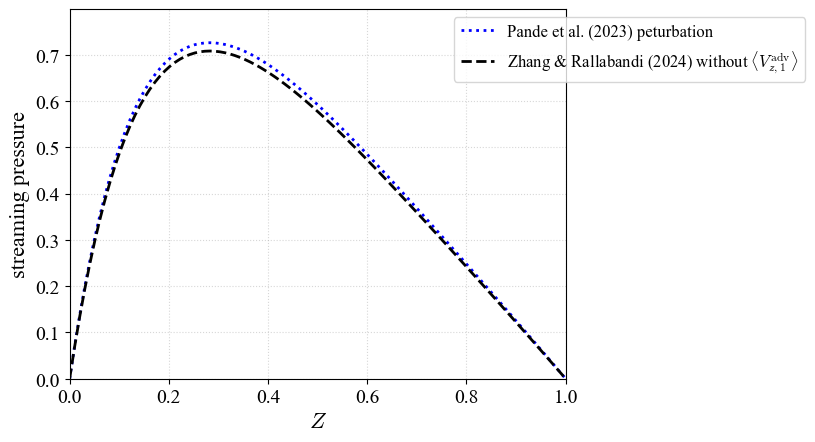

Wo = 1.4142135623730951, St = 2


In [35]:
my_St = 2
my_Wo = np.sqrt(2)

my_Z = np.linspace(0,1,100,endpoint=True)
my_streamP_ZR24 = lam_streamP_ZR24(my_Z,my_St,my_Wo)
my_streamP_PWC23 = lam_streamP_PWC23(my_Z,my_St,my_Wo)

ax = plt.gca()
ax.set_xlabel('$Z$')
ax.set_ylabel('streaming pressure')
ax.set_xlim(0, 1)
# casting to float due to weird behavior with lambdify
ylim_max = float(1.1*max(np.max(my_streamP_ZR24),
                         np.max(my_streamP_PWC23)))
ax.set_ylim(0, ylim_max)

ax.plot(my_Z, my_streamP_PWC23, ls='dotted', color='blue', lw=2,
        label='Pande et al. (2023) peturbation')
ax.plot(my_Z, my_streamP_ZR24, ls='dashed', color='black', lw=2,
        label=r'Zhang & Rallabandi (2024) without $\langle V_{z,1}^\mathrm{adv} \rangle$')

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend(bbox_to_anchor=(1, 0, 0.5, 1), loc='upper right')

plt.show()

print(f'Wo = {my_Wo}, St = {my_St}')

## Evaluating the advective inertia's contribution

Next, we wish to evaluate the inertial contribution
$$
  \left\langle V_{r,0} \frac{\partial V_{z,0}}{\partial R} + V_{z,0} \frac{\partial V_{z,0}}{\partial Z} \right\rangle = \left\langle V_{r,0} \frac{\partial V_{z,0}}{\partial R} \right\rangle + \left\langle V_{z,0} \frac{\partial V_{z,0}}{\partial Z} \right\rangle.
$$


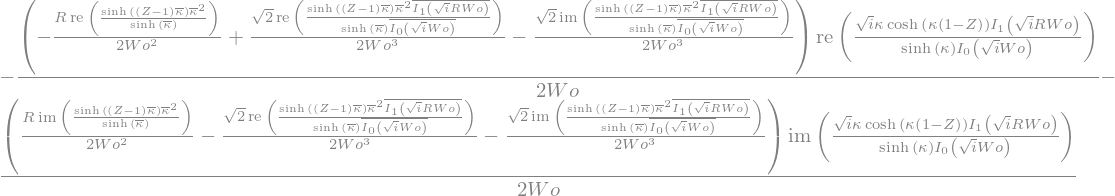

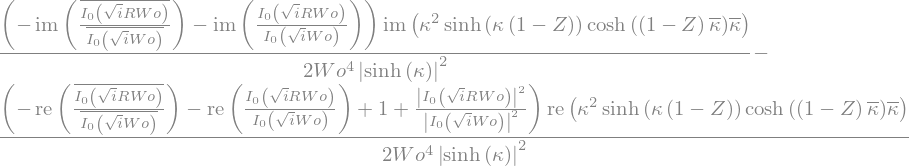

In [36]:
inertia_avg_term1 = sp.Rational(1,2)*sp.re(sp.conjugate(Vr0)*Vz0.diff(R))
display(inertia_avg_term1)
inertia_avg_term2 = sp.Rational(1,2)*sp.re(sp.conjugate(Vz0)*Vz0.diff(Z))
display(inertia_avg_term2)

This is pretty gnarly. We could try to expand the terms in  for $\mathrm{Wo}\ll1$ but it doesn't seem to converge...

In [37]:
#sp.series(Wo**2/St*(inertia_avg_term1+inertia_avg_term2).subs(kappa,sp.sqrt(2*sp.I*St/G0)),Wo,0,1).simplify()

The BVP for $\langle V_{z,1}^\mathrm{adv} \rangle$ is
$$
  \frac{\mathrm{Wo}^2}{\mathrm{St}} \left\langle V_{r,0} \frac{\partial V_{z,0}}{\partial R} + V_{z,0} \frac{\partial V_{z,0}}{\partial Z} \right\rangle =  \frac{1}{R}\frac{\partial }{\partial R} \left( R \frac{\partial
   \langle V_{z,1}^\mathrm{adv} \rangle}{\partial R} \right) = \frac{\partial^2 \langle V_{z,1}^\mathrm{adv} \rangle}{\partial R^2} +  \frac{1}{R}\frac{\partial \langle V_{z,1}^\mathrm{adv} \rangle}{\partial R},
$$

$$
  \left.\frac{\partial \langle V_{z,1}^\mathrm{adv} \rangle}{\partial R}\right|_{R=0} = \langle V_{z,1}^\mathrm{adv} \rangle|_{R=1} = 0.
$$
We will solve it numerically.

In [38]:
#f = sp.Function('f')
#avg_Vz1_adv = sp.dsolve(f(Y).diff(Y,Y) - Wo**2/sigma*(inertia_avg_term1+inertia_avg_term2),
#                        f(Y), ics={f(0):0, f(1):0}).rhs

In [39]:
avg_Vz1_adv_forcing = sp.lambdify((R,Z,St,Wo), Wo**2/St*(inertia_avg_term1+inertia_avg_term2).subs(kappa,sp.sqrt(2*sp.I*St/G0)))

In [40]:
def avg_Vz1_ode(R, V, Z, St, Wo):
  return np.vstack((V[1,:], avg_Vz1_adv_forcing(R,Z,St,Wo) - 1/R*V[1,:]))

def avg_Vz1_bc(Va, Vb):
  return np.array([Va[1], Vb[0]])

my_R = np.linspace(1e-6,1,100,endpoint=True) # avoid R = 0 singularity
V_guess = np.vstack((1-my_R**2,-2*my_R))

# finds $\langle V_{z,1}^\mathrm{adv} \rangle$
def Vz1_adv(Z,St,Wo):
  sol = solve_bvp(lambda R, V: avg_Vz1_ode(R, V, Z, St, Wo), avg_Vz1_bc, my_R, V_guess)
  return sol.sol(my_R)[0,:]

# computes $\int_0^1 \langle V_{z,1}^\mathrm{adv} \rangle R dR$
# allows for a vector input of Z values
def yint_Vz1_adv(Z,St,Wo):
  if np.isscalar(Z):
    sol = solve_bvp(lambda R, V: avg_Vz1_ode(R, V, Z, St, Wo), avg_Vz1_bc, my_R, V_guess)
    return trapezoid(sol.sol(my_R)[0,:]*my_R,my_R)
  else:
    output_array = np.zeros_like(Z)
    for i in range(0,Z.size):
      sol = solve_bvp(lambda R, V: avg_Vz1_ode(R, V, Z[i], St, Wo), avg_Vz1_bc, my_R, V_guess)
      output_array[i] = trapezoid(sol.sol(my_R)[0,:]*my_R,my_R)
    return output_array

We can plot $\langle V_{z,1}^\mathrm{adv} \rangle$ as a function of $R$ at different $Z$ locations, scaling the magnitudes to clearly fit on one plot.

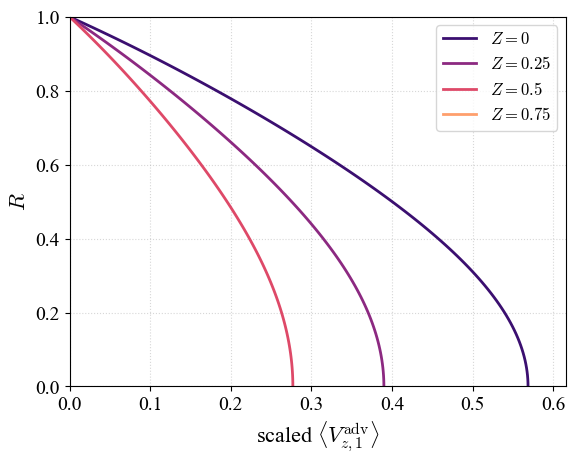

In [50]:
ax = plt.gca()
ax.set_ylabel('$R$')
ax.set_xlabel(r'scaled $\langle V_{z,1}^\mathrm{adv} \rangle$')
ax.set_ylim(0, 1)

# https://matplotlib.org/stable/users/explain/colors/colormaps.html#sequential
cmap = colormaps['magma']

ax.plot(Vz1_adv(0.0, my_St, my_Wo), my_R, lw=2, label='$Z=0$', color=cmap(1/5))
ax.plot(1e0*Vz1_adv(0.25, my_St, my_Wo), my_R, lw=2, label='$Z=0.25$', color=cmap(2/5))
ax.plot(2e0*Vz1_adv(0.5, my_St, my_Wo), my_R, lw=2, label='$Z=0.5$', color=cmap(3/5))
ax.plot(5e0*Vz1_adv(0.75, my_St, my_Wo), my_R, lw=2, label='$Z=0.75$', color=cmap(4/5))
#ax.plot(Vz1_adv(1, my_St, my_Wo), my_R, lw=2, label='$Z=1$')

ax.set_xlim(left=0)
ax.grid(alpha=0.5, linestyle='dotted')
ax.legend()

plt.show()

Now, we can redo the $\langle P_1 \rangle$ plot incorporating $\langle V_{z,1}^\mathrm{adv} \rangle$. So, we wish to evaluate
$$
    \langle Q_1 \rangle = 2\pi \int_0^1 \left[-\frac{1}{2}\left.\left\langle P_0 \frac{\partial V_{z,0}}{\partial R} \right|_{R=1}\right\rangle +  \int_0^1 \langle V_{z,1}^\mathrm{adv} \rangle \, dY \right]dZ
$$
and
$$
    \langle P_1 \rangle(Z) = 16 \int_0^Z \left[  -\frac{1}{2}\left.\left\langle P_0 \frac{\partial V_{z,0}}{\partial R} \right|_{R=1}\right\rangle + \int_0^1 \langle V_{z,1}^\mathrm{adv} \rangle \, dY \right] dZ - \frac{8}{\pi} Z \langle Q_1 \rangle
$$
using the identity $\langle A B \rangle = \tfrac{1}{2}\Re[A^*B]$.

In [42]:
my_St = 5
my_Wo = np.sqrt(2)

my_streamP_ZR24 = lam_streamP_ZR24(my_Z,my_St,my_Wo)

my_yint_Vz1_adv = yint_Vz1_adv(my_Z,my_St,my_Wo)

my_streamP_ZR24_w_Vz1_adv = lam_streamP_ZR24(my_Z,my_St,my_Wo) \
                            + 16*cumulative_trapezoid(my_yint_Vz1_adv,my_Z,initial=0) \
                            - 16*my_Z*trapezoid(my_yint_Vz1_adv,my_Z)

# my_streamP_ZR24_w_Vz1_adv = np.zeros_like(my_Z)
# for i in range(0,len(my_Z)):
#   my_streamP_ZR24_w_Vz1_adv[i] = lam_streamP_ZR24(my_Z[i],my_St,my_Wo) \
#                                  + 16*trapezoid(my_yint_Vz1_adv[0:i],my_Z[0:i]) \
#                                  - 16*my_Z[i]*trapezoid(my_yint_Vz1_adv,my_Z)

#my_streamP_PWC23 = lam_streamP_PWC23(my_Z,my_St,my_Wo)

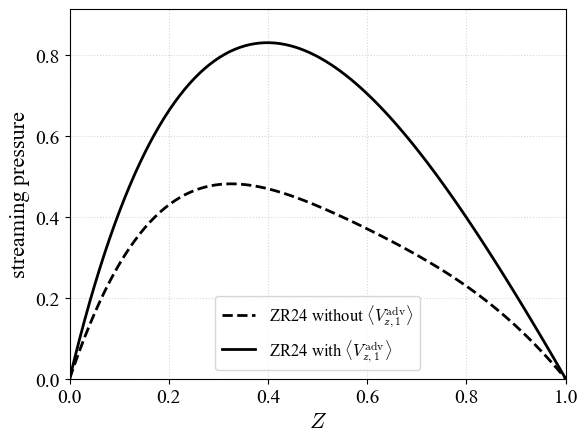

Wo = 2.23606797749979, St = 0.6307941057289874


In [51]:
ax = plt.gca()
ax.set_xlabel('$Z$')
ax.set_ylabel('streaming pressure')
ax.set_xlim(0, 1)
# casting to float due to weird behavior with lambdify
ylim_max = float(1.1*max(np.max(my_streamP_ZR24),
                         np.max(my_streamP_ZR24_w_Vz1_adv)))
#ylim_max = 1
ax.set_ylim(0, ylim_max)

#ax.plot(my_Z, my_streamP_PWC24, lw=2, ls='dotted', color='black',
#        label='PWC23 perturbation')
ax.plot(my_Z, my_streamP_ZR24, lw=2, ls='dashed', color='black',
        label=r'ZR24 without $\langle V_{z,1}^\mathrm{adv} \rangle$')
ax.plot(my_Z, my_streamP_ZR24_w_Vz1_adv, lw=2, color='black',
        label=r'ZR24 with $\langle V_{z,1}^\mathrm{adv} \rangle$')

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

plt.show()

print(f'Wo = {my_Wo}, St = {my_St}')

# Comparison with svFSI simulation data

In [44]:
# PWC23 post-processed data

# Sim_Wo_1_beta_0.0521_St_2.021.csv
my_color = '#EDB120'
beta_sim = 0.0521
Stf_sim = 2.021
Wo_sim = np.sqrt(1)
P_cycle_sim = np.array([-0.0794, 0.0032, 0.2428, 0.4582, 0.5362, 0.5411, 0.5006, 0.4369, 0.3448, 0.2384, 0.1234, 0.0000])
Zsim = np.array([0,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])

# Sim_Wo_3_beta_0.0501_St_2.093
my_color = '#D93319'
beta_sim = 0.0501
Stf_sim = 2.093
Wo_sim = np.sqrt(3)
P_cycle_sim = np.array([-0.1478, -0.0499, 0.2666, 0.5739, 0.7011, 0.7352, 0.6811, 0.6058, 0.4788, 0.3428, 0.1770, 0.0188])
Zsim = np.array([0,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])

# Sim_Wo_5_beta_0.0505_St_1.988
my_color = '#A2142F'
beta_sim = 0.0505
Stf_sim = 1.988
Wo_sim = np.sqrt(5)
P_cycle_sim = np.array([-0.1943, -0.2663, -0.1007, 0.2543, 0.6123, 0.7867, 0.8262, 0.8117, 0.7096, 0.5617, 0.4220, 0.1981, 0.0214])
Zsim = np.array([0,0.02,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])

In [45]:
my_St = Stf_sim*beta_sim*2*np.pi
my_Wo = Wo_sim

#my_Z = np.linspace(0,1,100,endpoint=True)

my_streamP_ZR24 = lam_streamP_ZR24(my_Z,my_St,my_Wo)

my_yint_Vz1_adv = yint_Vz1_adv(my_Z,my_St,my_Wo)

my_streamP_ZR24_w_Vz1_adv = my_streamP_ZR24 \
                            + 16*cumulative_trapezoid(my_yint_Vz1_adv,my_Z,initial=0) \
                            - 16*my_Z*trapezoid(my_yint_Vz1_adv,my_Z)

# my_streamP_ZR24_w_Vz1_adv = np.zeros_like(my_Z)
# for i in range(0,len(my_Z)):
#   my_streamP_ZR24_w_Vz1_adv[i] = lam_streamP_ZR24(my_Z[i],my_St,my_Wo) \
#                                  + 16*trapezoid(my_yint_Vz1_adv[0:i],my_Z[0:i]) \
#                                  - 16*my_Z[i]*trapezoid(my_yint_Vz1_adv,my_Z)

my_streamP_PWC23 = lam_streamP_PWC23(my_Z,my_St,my_Wo)

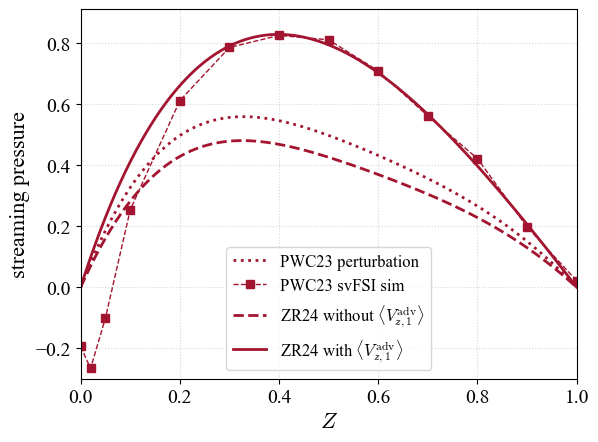

Wo = 2.23606797749979, St = 0.6307941057289874


In [46]:
ax = plt.gca()
ax.set_xlabel('$Z$')
ax.set_ylabel('streaming pressure')
ax.set_xlim(0, 1)
# casting to float due to weird behavior with lambdify
ylim_max = float(1.1*max(np.max(my_streamP_ZR24),
                         np.max(my_streamP_PWC23),
                         np.max(my_streamP_ZR24_w_Vz1_adv),
                         np.max(P_cycle_sim)))
ax.set_ylim(-0.3, ylim_max)

ax.plot(my_Z, my_streamP_PWC23, lw=2, ls='dotted', color=my_color,
        label='PWC23 perturbation')
ax.plot(Zsim, P_cycle_sim, 's--', lw=1, color=my_color,
        label='PWC23 svFSI sim')
ax.plot(my_Z, my_streamP_ZR24, lw=2, ls='dashed', color=my_color,
        label=r'ZR24 without $\langle V_{z,1}^\mathrm{adv} \rangle$')
ax.plot(my_Z, my_streamP_ZR24_w_Vz1_adv, lw=2, color=my_color,
        label=r'ZR24 with $\langle V_{z,1}^\mathrm{adv} \rangle$')

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

plt.show()

print(f'Wo = {my_Wo}, St = {my_St}')

If we wish to load raw PWC23 data and process it, but it is not necessary.

In [47]:
# from google.colab import drive
# drive.mount('/content/drive')

In [48]:
# SV_Wo1St2_df = pd.read_csv('/content/drive/MyDrive/PWC23/Sim_Wo_1_beta_0.0521_St_2.021.csv')
# ML_Wo1St2_contents = loadmat('/content/drive/MyDrive/PWC23/Numerical_Wo_1_beta_0.0521_St_2.021.mat')
# beta_sim = 0.0521
# Stf_sim = 2.021

# p_sim_1 = SV_Wo1St2_df.to_numpy()

# Psim_1 = p_sim_1/p_sim_1[90,0]
# # Pdist_sim1 = Psim_1[90,:]; # pressure distribution for svFSI solution
# # Pdist_sim2 = Psim_1[92,:];
# # Pdist_sim3 = Psim_1[94,:];
# # Pdist_sim4 = Psim_1[96,:];
# # Pdist_sim5 = Psim_1[98,:];
# # Pdist_sim6 = Psim_1[10,:];

# # this doesn't work !?
# P_cycle_sim_1 = trapezoid(Psim_1[90:100,:],dx=0.1,axis=0)/beta_sim # cycle averaged

# References

*   [PWC23] Shrihari D. Pande, Xiaojia Wang and Ivan C. Christov, "Oscillatory flows in compliant conduits at arbitrary Womersley number," Physical Review Fluids 8 (2023) 124102, [doi:10.1103/PhysRevFluids.8.124102](https://dx.doi.org/10.1103/PhysRevFluids.8.124102); preprint [arXiv:2304.00543](https://arxiv.org/abs/2304.00543).

*   [ZR24] Xirui Zhang and Bhargav Rallabandi, "Elasto-inertial rectification of oscillatory flow in an elastic tube," Journal of Fluid Mechanics 996 (2024) A16, [doi:10.1017/jfm.2024.612](https://doi.org/10.1017/jfm.2024.612); preprint [arXiv:2404.02292](https://arxiv.org/abs/2404.02292).

*   [GC19] Aditya A. Ghodgaonkar and Ivan C. Christov, "Solving Nonlinear Parabolic Equations by a Strongly Implicit Finite Difference Scheme: Applications to the Finite Speed Spreading of Non-Newtonian Viscous Gravity Currents," in: _Advanced Wave Mathematics II_, eds. T. Soomere and A. Berezovski, Springer Series on Mathematics of Planet Earth **6** (2019) 303&ndash;340, [doi:10.1007/978-3-030-29951-4_14](https://doi.org/10.1007/978-3-030-29951-4_14); preprint [arXiv:1903.07568](https://arxiv.org/abs/1903.07568).